In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import os
from dotenv import load_dotenv
import pickle

from torchvision import transforms
from torchvision.datasets import ImageFolder

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader

from PIL import Image

In [2]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report)

In [3]:
import warnings
warnings.filterwarnings('ignore')

**TO ACCESS DATA IN COLLAB**

In [4]:
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset/

Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset/versions/
License(s): copyright-authors
100% 2.70G/2.70G [02:30<00:00, 19.2MB/s]



In [5]:
import zipfile
with zipfile.ZipFile('new-plant-diseases-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

In [6]:
TRAIN_DIR = '/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train'
VALID_DIR = '/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid'
TEST_DIR = '/content/test/test'

**PRE INFO**

In [ ]:
load_dotenv()

TRAIN_DIR = os.getenv("train_folder")
TEST_DIR = os.getenv("test_folder")
VALID_DIR = os.getenv("valid_folder")

**TRANSFORMS and DATASET, DATALOADER**

In [7]:
IMAGE_SIZE = (224,224)
BATCH_SIZE = 32

**TRAIN AND VAL BLOCKS**

In [12]:
def train_block(model, train_dataloader, criterion, optimizer, device):
  model.to(device)
  model.train()

  total_batch_loss = 0.0
  correctly_predicted = 0
  total = 0

  for images, labels in train_dataloader:
    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()
    output = model(images)
    loss = criterion(output, labels)
    loss.backward()
    optimizer.step()

    total_batch_loss += loss.item()
    total += len(labels)
    _,predicted = torch.max(output, 1)
    correctly_predicted += (predicted == labels).sum().item()

  epoch_loss = total_batch_loss/len(train_dataloader)
  acc = correctly_predicted/total

  return epoch_loss, acc

In [13]:
def val_block(model, valid_dataloader, criterion, device):
  model.to(device)
  model.eval()

  total_batch_loss = 0.0
  correctly_predicted = 0
  total = 0

  with torch.no_grad():

    for images, labels in valid_dataloader:
      images = images.to(device)
      labels = labels.to(device)


      output = model(images)
      loss = criterion(output, labels)

      total_batch_loss += loss.item()
      total += len(labels)
      _,predicted = torch.max(output, 1)
      correctly_predicted += (predicted == labels).sum().item()

    epoch_loss = total_batch_loss/len(valid_dataloader)
    acc = correctly_predicted/total

  return epoch_loss, acc

**PRE TRAINED MODELS**

In [14]:
from torchvision import models

In [21]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

*MobileNetv02*

In [35]:
mbnet_weights = models.MobileNet_V2_Weights.DEFAULT
mbnet = models.mobilenet_v2(weights=mbnet_weights).to(device)

In [36]:
train_transforms = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.15),
    transforms.ToTensor()
])
valid_transforms = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor()
])

In [37]:
train_dataset = ImageFolder(TRAIN_DIR, transform=train_transforms)
valid_dataset = ImageFolder(VALID_DIR, transform=valid_transforms)

In [38]:
train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True
)

valid_dataloader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True
)

In [26]:
class_names = train_dataset.classes
num_classes = len(class_names)
num_classes

38

In [39]:
for param in mbnet.parameters():
    param.requires_grad = False

In [40]:
num_features = mbnet.classifier[1].in_features

In [41]:
mbnet.classifier = nn.Sequential(
            nn.Linear(num_features,num_classes)
)

In [45]:
learning_rate = 0.05
epochs = 10
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mbnet.parameters(), lr=learning_rate)

In [46]:
train_losses_mbnet = []
valid_losses_mbnet = []

train_accs_mbnet = []
valid_accs_mbnet = []

In [47]:
for epoch in range(epochs):

  train_loss, train_acc = train_block(mbnet, train_dataloader, criterion, optimizer, device)
  valid_loss, valid_acc = val_block(mbnet, valid_dataloader, criterion, device)

  train_losses_mbnet.append(train_loss)
  train_accs_mbnet.append(train_acc)

  valid_losses_mbnet.append(valid_loss)
  valid_accs_mbnet.append(valid_acc)

  print(f'epoch {epoch+1} train_loss {train_loss} train_acc {train_acc} valid_loss {valid_loss} valid_acc {valid_acc}')

epoch 1 train_loss 1.4702361834783784 train_acc 0.9105341773952628 valid_loss 1.416447221937773 valid_acc 0.9294331891645801
epoch 2 train_loss 1.4453975104243844 train_acc 0.9257699694146099 valid_loss 1.5438730641006964 valid_acc 0.9322217163669474
epoch 3 train_loss 1.5372250838544115 train_acc 0.9304075681058397 valid_loss 1.1111912726235047 valid_acc 0.9503186888231278
epoch 4 train_loss 1.4495602200016182 train_acc 0.9379045451312327 valid_loss 1.1967345388591228 valid_acc 0.9482130662417483
epoch 5 train_loss 1.4628658567975323 train_acc 0.9396258624368732 valid_loss 1.4228457063297197 valid_acc 0.951115410880947
epoch 6 train_loss 1.4878116697313264 train_acc 0.9428977878938758 valid_loss 1.3756612484493604 valid_acc 0.9531641247439108
epoch 7 train_loss 1.494603064034492 train_acc 0.945117006899495 valid_loss 1.2095530119565734 valid_acc 0.9565217391304348
epoch 8 train_loss 1.4469332061578297 train_acc 0.9478341276050928 valid_loss 1.5889881807855517 valid_acc 0.9447416344183

In [48]:
torch.save(mbnet.state_dict(), 'mbnet.pth')

In [49]:
with open('train_losses_mbnet.pkl','wb') as f:
  pickle.dump(train_losses_mbnet, f)

with open('valid_losses_mbnet.pkl','wb') as f:
  pickle.dump(valid_losses_mbnet, f)

with open('train_accs_mbnet.pkl','wb') as f:
  pickle.dump(train_accs_mbnet, f)

with open('valid_accs_mbnet.pkl','wb') as f:
  pickle.dump(valid_accs_mbnet, f)

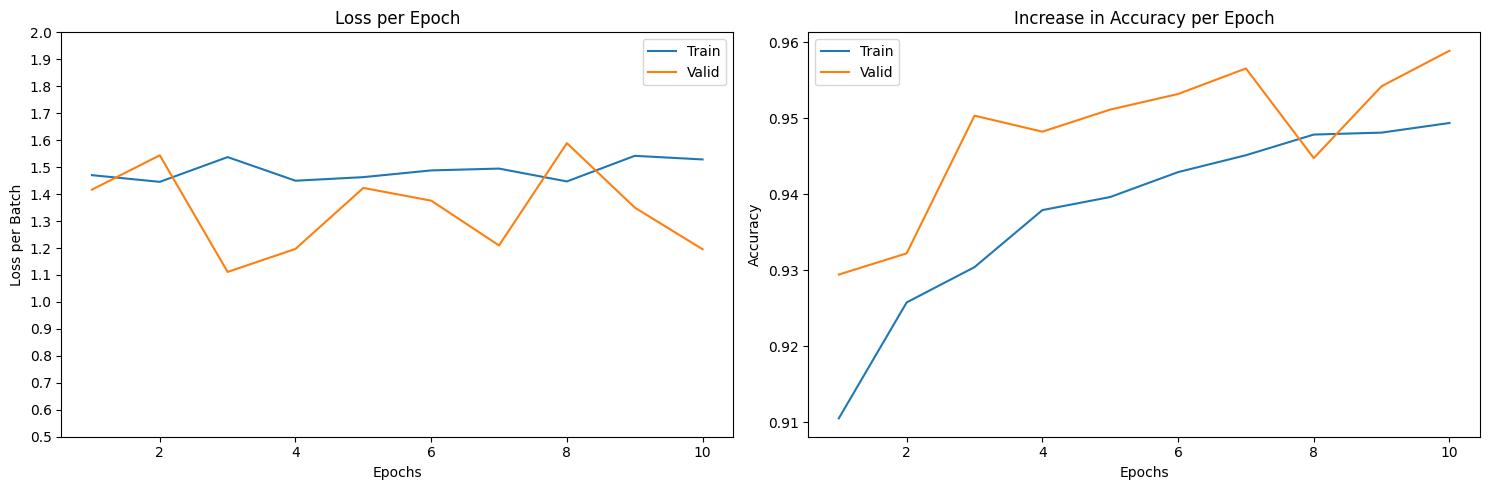

In [53]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.plot(range(1,11),train_losses_mbnet, label='Train')
plt.plot(range(1,11),valid_losses_mbnet, label='Valid')
plt.title('Loss per Epoch')
plt.yticks(np.arange(0.5,2.1,0.1))
plt.xlabel('Epochs')
plt.ylabel('Loss per Batch')
plt.legend()

plt.subplot(1,2,2)
plt.plot(range(1,11),train_accs_mbnet, label='Train')
plt.plot(range(1,11),valid_accs_mbnet, label='Valid')
plt.title('Increase in Accuracy per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()